<font>
<div dir=ltr align=center>
<img src='https://cdn.freebiesupply.com/logos/large/2x/sharif-logo-png-transparent.png' width=150 height=150> <br>
<font color=0F5298 size=6>
Machine Learning<br>
<font color=2565AE size=4>
Computer Engineering Department<br>
Fall 2025<br>
<font color=3C99D size=4>
Homework 3 - Practical<br>
<font color=696880 size=3>

# Reyhane Khayatzade-Mahani 402105965

# Libraries

In [1]:
import math
import time
import copy
import numpy as np
import matplotlib.pyplot as plt

# Part 1: Dataset

In [29]:
def set_seed(seed=42):
    """Return a NumPy Generator for reproducibility."""
    generator = np.random.default_rng(seed)
    return generator


def train_val_split(X, y, val_ratio=0.2, seed=42):
    """Split X, y into train/val using a shuffled index.

    Returns:
        X_train, y_train, X_val, y_val
    """
    generator = set_seed(seed)
    n = X.shape[0]
    idx = np.arange(n)
    generator.shuffle(idx)

    # TO DO
    val_size = int(n * val_ratio)
    train_idx = idx[:-val_size]
    val_idx = idx[-val_size:]
    X_train = X[train_idx]
    y_train = y[train_idx]
    X_val = X[val_idx]
    y_val = y[val_idx]
    return X_train, y_train, X_val, y_val

def standardize(X_train, X_val):
    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0, ddof=0)
    eps = 1e-8
    X_train_norm = (X_train - mean) / (std + eps)
    X_val_norm = (X_val - mean) / (std + eps)
    return X_train_norm, X_val_norm

In [102]:
def make_blobs(n_samples=1000, n_features=2, centers=3, cluster_std=1.0, seed=42):
    """Generate a simple clustered dataset (features X, integer labels y)."""
    generator = set_seed(seed)
    
    if isinstance(centers, int):
        # Draw centers from normal (similar to sklearn's default behavior)
        center_scale = 4.0  # adjust this to control separation; 4.0 works well
        centers_coords = generator.normal(0, center_scale, size=(centers, n_features))
    else:
        centers_coords = np.array(centers)
    
    n_centers = centers_coords.shape[0]
    
    samples_per_center = [n_samples // n_centers] * n_centers
    for i in range(n_samples % n_centers):
        samples_per_center[i] += 1
    
    X_list = []
    y_list = []
    for i, count in enumerate(samples_per_center):
        X_cluster = generator.normal(loc=centers_coords[i], scale=cluster_std, size=(count, n_features))
        y_cluster = np.full(count, i, dtype=int)
        X_list.append(X_cluster)
        y_list.append(y_cluster)
    
    X = np.concatenate(X_list, axis=0)
    y = np.concatenate(y_list, axis=0)
    
    return X, y

In [103]:
X, y = make_blobs(n_samples=1200, n_features=10, centers=5, cluster_std=1.3)
X_train_raw, y_train_raw, X_val_raw, y_val_raw = train_val_split(X, y, val_ratio=0.2)
X_train, X_val = standardize(X_train_raw, X_val_raw)
y_train, y_val = y_train_raw, y_val_raw

In [104]:
num_classes = int(y.max() + 1)
input_dim = X_train.shape[1]
print('Train shape:', X_train.shape, 'Val shape:', X_val.shape, 'Classes:', num_classes)

Train shape: (960, 10) Val shape: (240, 10) Classes: 5


# Part 2: MLP Layers

In [105]:
class Layer:
    """Base class for layers.

    Methods to implement in subclasses:
      - forward(x, training=True): returns output tensor
      - backward(dout): returns gradient w.r.t. input (dx)

    Convention:
      - Trainable parameters are kept in self.params (dict)
      - Their gradients are kept in self.grads (dict)
    """

    def __init__(self):
        # You usually do NOT change this part.
        # It provides dictionaries that child classes will fill.
        self.params = {}
        self.grads = {}

    def forward(self, x, training=True):
        """
        Forward pass of the layer.

        TODO (in subclasses):
          - Take input x and return the output tensor.
          - Use `training` if the layer behaves differently in train/test
            (e.g., Dropout, BatchNorm).

        This base class just defines the interface and should be overridden.
        """
        raise NotImplementedError("forward() must be implemented in subclasses.")

    def backward(self, dout):
        """
        Backward pass of the layer.

        TODO (in subclasses):
          - Take upstream gradient dout and return gradient w.r.t. input (dx).
          - Also fill self.grads[...] for any trainable parameters.

        This base class just defines the interface and should be overridden.
        """
        raise NotImplementedError("backward() must be implemented in subclasses.")

    def parameters(self):
        """Yield (name, param_array, grad_array) pairs for trainer/optimizer.

        You typically don't need to modify this:
          - Used by the optimizer to iterate over all trainable params.
        """
        for k, v in self.params.items():
            yield k, v, self.grads[k]

In [106]:
class Linear(Layer):
    """Affine layer: y = xW + b.

    Args:
        - init: 'he' or 'xavier' for weight initialization

    What to implement:
      - forward: cache x, return x @ W + b
      - backward: compute dW = x^T @ dout, db = sum(dout), dx = dout @ W^T
      - store grads in self.grads['W'], self.grads['b']
    """

    def __init__(self, in_features, out_features, init='he', seed=42):
        super().__init__()

        if init == 'xavier':
            scale = math.sqrt(2.0 / (in_features + out_features))
        else:
            scale = math.sqrt(2.0 / in_features)

        generator = np.random.default_rng(seed)
        W = generator.normal(0.0, scale, size=(in_features, out_features)).astype(np.float64)
        b = np.zeros((out_features,), dtype=np.float64)

        self.params['W'] = W
        self.params['b'] = b
        self.grads['W'] = np.zeros_like(W)
        self.grads['b'] = np.zeros_like(b)
        self.cache = None

    def forward(self, x, training=True):
        self.cache = x
        out = x @ self.params['W'] + self.params['b']
        return out

    def backward(self, dout):
        x = self.cache
        dW = x.T @ dout
        db = dout.sum(axis=0)
        self.grads['W'][:] = dW
        self.grads['b'][:] = db
        dx = dout @ self.params['W'].T
        return dx

In [107]:
class ReLU(Layer):
    """Rectified Linear Unit: ReLU(x) = max(0, x)."""

    def __init__(self):
        super().__init__()
        self.mask = None

    def forward(self, x, training=True):
        self.mask = (x > 0)
        out = x * self.mask
        return out

    def backward(self, dout):
        dx = dout * self.mask
        return dx


class Tanh(Layer):
    """Elementwise tanh activation."""

    def __init__(self):
        super().__init__()
        self.cache = None

    def forward(self, x, training=True):
        out = np.tanh(x)
        self.cache = out
        return out

    def backward(self, dout):
        out = self.cache
        dx = dout * (1 - out * out)
        return dx

In [108]:
class Dropout(Layer):
    """Inverted Dropout.

    Args:
        p: drop probability in (0, 1). During training, we set some activations
           to zero and scale the rest by 1/(1-p) so expectation stays constant.

    What to implement:
      - forward:
          if training: sample mask from Bernoulli(keep_prob) and scale by 1/(1-p)
                       return x * mask (store mask)
          else: return x unchanged
      - backward:
          if training: return dout * mask
          else: return dout unchanged
    """

    def __init__(self, p=0.5, seed=42):
        super().__init__()
        assert 0.0 <= p < 1.0

        self.p = float(p)
        self.keep = 1.0 - self.p
        self.generator = np.random.default_rng(seed)
        self.mask = None

    def forward(self, x, training=True):
        if not training or self.p == 0.0:
            self.mask = None
            return x
        
        raw_mask = (self.generator.random(x.shape) < self.keep)
        self.mask = raw_mask.astype(np.float64) / self.keep
        return x * self.mask

    def backward(self, dout):
        if self.mask is None:
            return dout
        return dout * self.mask

In [109]:
class BatchNorm1d(Layer):
    """Batch Normalization for 2D inputs (N, D).

    What to implement:
      - forward (train): compute batch mean/var, normalize, scale/shift by gamma/beta,
                         update running stats (mean/var), cache intermediates
      - forward (eval): normalize using running stats
      - backward: gradients for gamma/beta and dx via BN derivatives
    """

    def __init__(self, num_features, momentum=0.9, eps=1e-5):
        super().__init__()

        self.params['gamma'] = np.ones((num_features,), dtype=np.float64)
        self.params['beta'] = np.zeros((num_features,), dtype=np.float64)
        self.grads['gamma'] = np.zeros_like(self.params['gamma'])
        self.grads['beta'] = np.zeros_like(self.params['beta'])

        self.momentum = momentum
        self.eps = eps
        self.running_mean = np.zeros((num_features,), dtype=np.float64)
        self.running_var = np.ones((num_features,), dtype=np.float64)

        self.cache = None

    def forward(self, x, training=True):
        gamma = self.params['gamma']
        beta = self.params['beta']

        if training:
            mu = x.mean(axis=0)
            var = x.var(axis=0)
            x_mu = x - mu
            std_inv = 1.0 / np.sqrt(var + self.eps)
            x_hat = x_mu * std_inv
            out = gamma * x_hat + beta

            self.running_mean = self.momentum * self.running_mean + (1 - self.momentum) * mu
            self.running_var = self.momentum * self.running_var + (1 - self.momentum) * var

            self.cache = (x, x_hat, mu, var, std_inv)
        else:
            x_hat = (x - self.running_mean) / np.sqrt(self.running_var + self.eps)
            out = gamma * x_hat + beta

        return out

    def backward(self, dout):
        x, x_hat, mu, var, std_inv = self.cache
        gamma = self.params['gamma']
        N = x.shape[0]

        dgamma = np.sum(dout * x_hat, axis=0)
        dbeta = np.sum(dout, axis=0)
        self.grads['gamma'][:] = dgamma
        self.grads['beta'][:] = dbeta

        dx_hat = dout * gamma
        x_mu = x - mu

        dvar = np.sum(dx_hat * x_mu, axis=0) * (-0.5) * (std_inv ** 3)
        dmu = np.sum(dx_hat * -std_inv, axis=0) + dvar * np.mean(-2 * x_mu, axis=0)

        dx = dx_hat * std_inv + (2 * dvar * x_mu) / N + dmu / N

        return dx

# Part 3: Loss

In [110]:
def softmax_cross_entropy(logits, y):
    """Stable softmax + cross-entropy for integer labels.

    Inputs:
      - logits: shape (N, C)
      - y: int labels in [0, C-1], shape (N,)
    Returns:
      - loss (scalar), dlogits (shape (N, C))

    What to implement:
      - shift logits by row max for stability
      - compute softmax probs, CE loss, and gradient dL/dlogits
    """

    shifted = logits - logits.max(axis=1, keepdims=True)

    exp = np.exp(shifted)

    probs = exp / exp.sum(axis=1, keepdims=True)

    N = logits.shape[0]
    loss = -np.log(probs[np.arange(N), y] + 1e-12).mean()

    dlogits = probs.copy()
    dlogits[np.arange(N), y] -= 1
    dlogits /= N

    return loss, dlogits

# Part 4: MLP

In [111]:
class MLP:
    """Multi-Layer Perceptron with optional BatchNorm and Dropout.

    Construction:
      dims = [input_dim] + hidden_sizes + [num_classes]
      For each hidden layer i:
        Linear(dims[i], dims[i+1]) -> [BatchNorm] -> Activation -> [Dropout]
      Output layer is Linear -> logits

    Args:
      activation: 'relu' or 'tanh'
      use_batchnorm: insert BatchNorm before activation if True
      dropout_p: probability to drop activations (0.0 disables)
      init: 'he' or 'xavier' for Linear layers
    """

    def __init__(self, input_dim, hidden_sizes, num_classes,
                 activation='relu', use_batchnorm=False, dropout_p=0.0, init='he', seed=42):
        self.layers = []
        generator = np.random.default_rng(seed)
        act_cls = ReLU if activation == 'relu' else Tanh
        dims = [input_dim] + list(hidden_sizes) + [num_classes]

        for i in range(len(dims) - 1):
            self.layers.append(
                Linear(dims[i], dims[i + 1], init=init, seed=int(generator.integers(0, 1e9)))
            )
            if i < len(dims) - 2:
                if use_batchnorm:
                    self.layers.append(BatchNorm1d(dims[i + 1]))
                self.layers.append(act_cls())
                if dropout_p and dropout_p > 0.0:
                    self.layers.append(Dropout(p=dropout_p, seed=int(generator.integers(0, 1e9))))

        self.training = True

    def forward(self, x, training=True):
        out = x
        for layer in self.layers:
            out = layer.forward(out, training=training)
        return out

    def backward(self, dout):
        for layer in reversed(self.layers):
            dout = layer.backward(dout)
        return dout

    def parameters(self):
        for layer in self.layers:
            if isinstance(layer, Layer):
                for name, param, grad in layer.parameters():
                    yield id(param), name, param, grad, layer

    def zero_grads(self):
        for _, _, _, grad, _ in self.parameters():
            grad[...] = 0.0

    def predict(self, x):
        logits = self.forward(x, training=False)
        preds = logits.argmax(axis=1)
        return preds

    def accuracy(self, x, y):
        preds = self.predict(x)
        acc = (preds == y).mean()
        return acc

## Numerical gradient check (sanity)
We compare analytical gradients vs. finite differences on a tiny network and batch.

In [112]:
def numerical_grad_check(model, X_batch, y_batch, eps=1e-5, atol=1e-6, rtol=1e-3, verbose=False):
    """Finite-difference gradient check.

    What to implement:
      - Forward to compute loss and analytical grads (via backward)
      - For a few random parameter entries: perturb +-eps and estimate numeric grad
      - Compare numeric vs. analytic with tolerances

    Inputs:
      - model: an object with forward, backward, zero_grads, and parameters() methods
      - X_batch: input batch, shape (N, D)
      - y_batch: integer labels, shape (N,)
      - eps: finite-difference step size
      - atol, rtol: absolute and relative tolerances for np.isclose
      - verbose: if True, print details on any mismatched gradients

    Returns:
      - ok: True if all checked gradients are close, False otherwise
    """

    logits = model.forward(X_batch, training=True)

    loss, dout = softmax_cross_entropy(logits, y_batch)

    model.zero_grads()

    model.backward(dout)

    ok = True

    for pid, name, param, grad, layer in model.parameters():
        if param is None or grad is None:
            continue

        flat = param.reshape(-1)
        gflat = grad.reshape(-1)

        rng = np.random.default_rng(0)
        num_check = min(5, len(flat))
        if num_check == 0:
            continue
        idxs = rng.choice(len(flat), size=num_check, replace=False)

        for idx in idxs:
            old = flat[idx]

            flat[idx] = old + eps
            logits_pos = model.forward(X_batch, training=True)
            loss_pos, _ = softmax_cross_entropy(logits_pos, y_batch)

            flat[idx] = old - eps
            logits_neg = model.forward(X_batch, training=True)
            loss_neg, _ = softmax_cross_entropy(logits_neg, y_batch)

            flat[idx] = old

            g_num = (loss_pos - loss_neg) / (2 * eps)
            g_ana = gflat[idx]

            if not np.isclose(g_num, g_ana, atol=atol, rtol=rtol):
                ok = False
                if verbose:
                    print(f"Grad mismatch in {layer.__class__.__name__}.{name}: "
                          f"numeric={g_num:.6e}, analytic={g_ana:.6e}")

    return ok

In [113]:
# Run a quick check (no dropout during grad check)
Xb = X_train[:8].astype(np.float64)
yb = y_train[:8]

tiny = MLP(input_dim=input_dim, hidden_sizes=[8], num_classes=num_classes,
           activation='relu', use_batchnorm=True, dropout_p=0.0, init='he', seed=123)

ok = numerical_grad_check(tiny, Xb, yb, eps=1e-6, atol=1e-8, rtol=1e-5, verbose=True)

print('Gradient check passed?', ok)

Gradient check passed? True


# Part 4: Optimizers
We implement: SGD, Momentum, Nesterov, RMSProp, Adam, AdamW (decoupled weight decay).

In [114]:
class Optimizer:
    """Base optimizer holding a learning rate and per-parameter state.

    What to implement (in subclasses):
      - step(params_and_grads):
          * Iterate over (pid, param, grad, layer_state) or similar tuples.
          * For each parameter:
              - Use self._get_state(pid) to access per-parameter state dict.
              - Read / initialize any state you need (e.g., momentum, v, m, etc.).
              - Apply your update rule:
                    param[...] = param + update   (usually minus lr * grad)
    """

    def __init__(self, lr=1e-2):
        self.lr = lr
        self.state = {}

    def step(self, params_and_grads):
        raise NotImplementedError("step() must be implemented in subclasses.")

    def _get_state(self, pid):
        if pid not in self.state:
            self.state[pid] = {}
        return self.state[pid]

In [115]:
class SGD(Optimizer):
    """Stochastic Gradient Descent (SGD)

    For each parameter w with gradient g at step t:
      w = w - lr * g

    What to implement:
      - In step():
          * Loop over all (pid, name, param, grad, layer) in params_and_grads
          * Update each parameter in-place with:
                param[...] = param - lr * grad
    """

    def step(self, params_and_grads):
        """
        Apply one SGD update to all parameters.

        Inputs:
          - params_and_grads: iterable of
                (pid, name, param, grad, layer)

        TODO:
          1. Loop over all entries in params_and_grads.
          2. For each (pid, name, p, g, layer):
               - Optionally skip if g is None.
               - Update the parameter p in-place:
                    p[...] = p - self.lr * g

        Hint:
          - Use p[...] instead of p = ... to modify the array in-place.
        """
        for pid, name, param, grad, layer in params_and_grads:
            if grad is None:
                continue
            param[...] -= self.lr * grad

In [116]:
class SGDMomentum(Optimizer):
    """SGD with momentum (Polyak)

    State per parameter: velocity v.

    Update at step t:
      v = mu * v - lr * g
      w = w + v

    Where mu is momentum in [0, 1).
    """

    def __init__(self, lr=1e-2, momentum=0.9):
        super().__init__(lr)
        self.momentum = momentum

    def step(self, params_and_grads):
        """
        Apply one SGD-with-momentum update to all parameters.

        Inputs:
          - params_and_grads: iterable of
                (pid, name, param, grad, layer)

        TODO:
          1. Loop over all (pid, name, p, g, layer) in params_and_grads.
          2. For each parameter:
               - Optionally skip if g is None.
               - Get (or create) its state dict:
                    st = self._get_state(pid)
               - Get velocity from state, defaulting to zeros of same shape:
                    v = st.get('v', np.zeros_like(p))
               - Update velocity using:
                    v = self.momentum * v - self.lr * g
               - Update parameter using:
                    p[...] = p + v
               - Store updated velocity back into state:
                    st['v'] = v

        Hint:
          - Use np.zeros_like(p) for initializing v.
          - Use p[...] for in-place update.
        """
        for pid, name, param, grad, layer in params_and_grads:
            if grad is None:
                continue
            st = self._get_state(pid)
            v = st.get('v', np.zeros_like(param))
            v = self.momentum * v - self.lr * grad
            param[...] += v
            st['v'] = v

In [117]:
class Nesterov(Optimizer):
    """Nesterov accelerated gradient (lookahead momentum)

    State per parameter: velocity v.

    Practical single-gradient update (equivalent to lookahead form):
      v_t = mu * v_prev - lr * g_t
      w_{t+1} = w_t + ( -mu * v_prev + (1 + mu) * v_t )

    This matches computing the gradient at the lookahead point
    (w_t + mu * v_prev) without an extra forward/backward pass.
    """

    def __init__(self, lr=1e-2, momentum=0.9):
        super().__init__(lr)
        self.momentum = momentum

    def step(self, params_and_grads):
        """
        Apply one Nesterov accelerated gradient update to all parameters.

        Inputs:
          - params_and_grads: iterable of
                (pid, name, param, grad, layer)

        TODO:
          1. Loop over all (pid, name, p, g, layer) in params_and_grads.
          2. For each parameter:
               - Optionally skip if g is None.
               - Get (or create) its state dict:
                    st = self._get_state(pid)
               - Get previous velocity from state, defaulting to zeros:
                    v_prev = st.get('v', np.zeros_like(p))
               - Compute new velocity:
                    v = self.momentum * v_prev - self.lr * g
               - Update parameter using Nesterov rule:
                    p[...] = p + (-self.momentum * v_prev + (1 + self.momentum) * v)
               - Store updated velocity back to state:
                    st['v'] = v

        Hint:
          - Use np.zeros_like(p) for initializing v_prev.
          - Use p[...] to update parameters in-place.
        """
        for pid, name, param, grad, layer in params_and_grads:
            if grad is None:
                continue
            st = self._get_state(pid)
            v_prev = st.get('v', np.zeros_like(param))
            v = self.momentum * v_prev - self.lr * grad
            param[...] += -self.momentum * v_prev + (1 + self.momentum) * v
            st['v'] = v

In [118]:
class RMSProp(Optimizer):
    """RMSProp

    State per parameter: s (running average of squared gradients).

    Update at step t:
      s = rho * s + (1 - rho) * (g^2)
      w = w - lr * g / (sqrt(s) + eps)

    Typical values: rho=0.9, eps=1e-8.
    """

    def __init__(self, lr=1e-3, rho=0.9, eps=1e-8):
        super().__init__(lr)
        self.rho = rho
        self.eps = eps

    def step(self, params_and_grads):
        """
        Apply one RMSProp update to all parameters.

        Inputs:
          - params_and_grads: iterable of
                (pid, name, param, grad, layer)

        TODO:
          1. Loop over all (pid, name, p, g, layer) in params_and_grads.
          2. For each parameter:
               - Optionally skip if g is None.
               - Get (or create) its state dict:
                    st = self._get_state(pid)
               - Retrieve running average of squared gradients, defaulting to zeros:
                    cache = st.get('cache', np.zeros_like(p))
               - Update running average:
                    cache = self.rho * cache + (1 - self.rho) * (g * g)
               - Compute parameter update:
                    p[...] = p - self.lr * g / (np.sqrt(cache) + self.eps)
               - Store updated cache back into state:
                    st['cache'] = cache

        Hints:
          - Use np.zeros_like(p) for initializing cache.
          - Use elementwise operations with NumPy.
          - Use p[...] to ensure in-place update of the parameter.
        """
        for pid, name, param, grad, layer in params_and_grads:
            if grad is None:
                continue
            st = self._get_state(pid)
            cache = st.get('cache', np.zeros_like(param))
            cache = self.rho * cache + (1 - self.rho) * (grad * grad)
            param[...] -= self.lr * grad / (np.sqrt(cache) + self.eps)
            st['cache'] = cache

In [119]:
class Adam(Optimizer):
    """Adam (with optional decoupled weight decay, AdamW)

    State per parameter: first moment m, second moment v, time step t.

    Moment updates at step t:
      m = beta1 * m + (1 - beta1) * g
      v = beta2 * v + (1 - beta2) * (g^2)

    Bias correction:
      m_hat = m / (1 - beta1**t)
      v_hat = v / (1 - beta2**t)

    Parameter update:
      w = w - lr * m_hat / (sqrt(v_hat) + eps)

    Decoupled weight decay (AdamW):
      if decoupled and weight_decay > 0:
          w = w - lr * weight_decay * w
      then apply the Adam step above.

    Typical values: beta1=0.9, beta2=0.999, eps=1e-8.
    """

    def __init__(self, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8, weight_decay=0.0, decoupled=False):
        super().__init__(lr)

        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.weight_decay = weight_decay
        self.decoupled = decoupled
        self.t = 0

    def step(self, params_and_grads):
        """
        Apply one Adam / AdamW update to all parameters.

        Inputs:
          - params_and_grads: iterable of
                (pid, name, param, grad, layer)

        TODO:
          1. Increment global time step:
               self.t += 1

          2. Loop over all (pid, name, p, g, layer) in params_and_grads:
               for pid, name, p, g, layer in params_and_grads:

             Inside the loop:

             a) Optionally skip if g is None.

             b) Get (or create) state dict for this parameter:
                  st = self._get_state(pid)

             c) Retrieve first and second moments, defaulting to zeros:
                  m = st.get('m', np.zeros_like(p))
                  v = st.get('v', np.zeros_like(p))

             d) If using decoupled weight decay (AdamW):
                  if self.decoupled and self.weight_decay > 0.0:
                      p[...] = p - self.lr * self.weight_decay * p

             e) Update biased first and second moments:
                  m = self.beta1 * m + (1 - self.beta1) * g
                  v = self.beta2 * v + (1 - self.beta2) * (g * g)

             f) Compute bias-corrected moments:
                  m_hat = m / (1 - self.beta1 ** self.t)
                  v_hat = v / (1 - self.beta2 ** self.t)

             g) Apply Adam parameter update:
                  p[...] = p - self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

             h) Store updated moments back into state:
                  st['m'] = m
                  st['v'] = v
        """
        self.t += 1

        for pid, name, param, grad, layer in params_and_grads:
            if grad is None:
                continue

            st = self._get_state(pid)
            m = st.get('m', np.zeros_like(param))
            v = st.get('v', np.zeros_like(param))

            if self.decoupled and self.weight_decay > 0.0:
                param[...] -= self.lr * self.weight_decay * param

            m = self.beta1 * m + (1 - self.beta1) * grad
            v = self.beta2 * v + (1 - self.beta2) * (grad * grad)

            m_hat = m / (1 - self.beta1 ** self.t)
            v_hat = v / (1 - self.beta2 ** self.t)

            param[...] -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

            st['m'] = m
            st['v'] = v

# Part 5: L1/L2 Regularization

In [120]:
def apply_weight_regularization(model, l1=0.0, l2=0.0):
    """Add L1/L2 penalties to Linear weights and accumulate gradients.

    What to implement:
      - For each Linear layer, add l2 * W to dW and 0.5*l2*||W||^2 to loss
      - Add l1 * sign(W) to dW and l1*|W| to loss

    Inputs:
      - model: an MLP-like object with a .layers list
      - l1: L1 regularization strength (float)
      - l2: L2 regularization strength (float)

    Returns:
      - regularization_loss: scalar float, sum of all L1/L2 penalties
    """

    regularization_loss = 0.0

    for layer in model.layers:
        if isinstance(layer, Linear):
            W = layer.params['W']
            dW = layer.grads['W']

            if l2 > 0.0:
                regularization_loss += 0.5 * l2 * np.sum(W * W)
                dW[...] += l2 * W

            if l1 > 0.0:
                regularization_loss += l1 * np.sum(np.abs(W))
                dW[...] += l1 * np.sign(W)

    return regularization_loss

# Part 6: Training Loop

In [121]:
def iterate_minibatches(X, y, batch_size, shuffle=True, seed=42):
    """Yield mini-batches (Xb, yb).

    What to implement:
      - Optionally shuffle indices using a fixed RNG (set_seed)
      - Loop over the dataset in chunks of size batch_size
      - For each chunk, yield X[batch_idx], y[batch_idx]

    Inputs:
      - X: input data of shape (N, D) or similar
      - y: labels of shape (N,)
      - batch_size: number of samples per mini-batch
      - shuffle: if True, shuffle the order of samples
      - seed: random seed for reproducible shuffling

    Yields:
      - (Xb, yb): mini-batch of inputs and labels
    """

    generator = set_seed(seed)
    n = X.shape[0]
    idx = np.arange(n)

    if shuffle:
        generator.shuffle(idx)

    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        batch_idx = idx[start:end]
        yield X[batch_idx], y[batch_idx]

In [122]:
def train(model, optimizer, X_train, y_train, X_val, y_val,
          epochs=30, batch_size=64, l1=0.0, l2=0.0,
          early_stopping_patience=5, seed=42, verbose=True,
          micro_batch_size=None):
    """
    Training loop with optional micro-batching (gradient accumulation).

    If micro_batch_size is set and smaller than batch_size, each training batch
    (size=batch_size) is split into micro-batches of size micro_batch_size.
    We accumulate gradients over micro-batches and call optimizer.step() once
    per (logical) batch. We weight both loss and grads so the result equals
    the mean over the full logical batch.

    Inputs:
      - model: MLP instance (or similar) with forward/backward/parameters/accuracy methods
      - optimizer: Optimizer instance with .step()
      - X_train, y_train: training data and labels
      - X_val,   y_val:   validation data and labels
      - epochs: number of passes over the training set
      - batch_size: logical batch size for training
      - l1, l2: L1/L2 regularization strengths
      - early_stopping_patience: #epochs to wait for val_loss improvement
      - seed: base seed for minibatch shuffling
      - verbose: print training progress if True
      - micro_batch_size: if not None and < batch_size, enable gradient accumulation

    Returns:
      - history: dict with keys 'train_loss', 'val_loss', 'train_acc', 'val_acc'
    """

    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': []
    }

    best_val_loss = np.inf
    best_params = None
    patience_counter = 0

    use_accumulation = micro_batch_size is not None and micro_batch_size < batch_size

    for epoch in range(1, epochs + 1):
        train_losses = []

        # Shuffle with epoch-specific seed for reproducibility
        epoch_seed = seed + epoch
        for Xb, yb in iterate_minibatches(X_train, y_train, batch_size, shuffle=True, seed=epoch_seed):
            if not use_accumulation:
                # Standard full-batch processing
                logits = model.forward(Xb, training=True)
                loss, dout = softmax_cross_entropy(logits, yb)

                model.zero_grads()
                model.backward(dout)

                reg_loss = apply_weight_regularization(model, l1=l1, l2=l2)
                loss += reg_loss

                optimizer.step(model.parameters())

                train_losses.append(loss)
            else:
                # Gradient accumulation with micro-batches
                Nvirt = len(Xb)
                model.zero_grads()
                total_loss = 0.0

                num_micro = int(np.ceil(Nvirt / micro_batch_size))
                for i in range(num_micro):
                    start = i * micro_batch_size
                    end = min(start + micro_batch_size, Nvirt)
                    X_micro = Xb[start:end]
                    y_micro = yb[start:end]

                    logits_micro = model.forward(X_micro, training=True)
                    micro_loss, micro_dout = softmax_cross_entropy(logits_micro, y_micro)

                    # Scale gradient to contribute 1/Nvirt of the total
                    scaled_dout = micro_dout * (len(X_micro) / Nvirt)
                    model.backward(scaled_dout)

                    total_loss += micro_loss * (len(X_micro) / Nvirt)

                # Apply regularization once per logical batch
                reg_loss = apply_weight_regularization(model, l1=l1, l2=l2)
                total_loss += reg_loss

                optimizer.step(model.parameters())

                train_losses.append(total_loss)

        # Epoch-level statistics
        epoch_train_loss = np.mean(train_losses)
        epoch_train_acc = model.accuracy(X_train, y_train)

        # Validation
        val_logits = model.forward(X_val, training=False)
        val_loss, _ = softmax_cross_entropy(val_logits, y_val)
        val_acc = model.accuracy(X_val, y_val)

        # Logging
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if verbose:
            print(f"Epoch {epoch:02d} | "
                  f"Train loss: {epoch_train_loss:.4f} acc: {epoch_train_acc:.4f} | "
                  f"Val   loss: {val_loss:.4f} acc: {val_acc:.4f}")

        # Early stopping check
        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            best_params = {pid: param.copy() for pid, _, param, _, _ in model.parameters()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= early_stopping_patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch}")
                break

    # Restore best parameters if we have them
    if best_params is not None:
        for pid, _, param, _, _ in model.parameters():
            if pid in best_params:
                param[...] = best_params[pid]

    return history

In [123]:
model = MLP(
    input_dim=X_train.shape[1],
    hidden_sizes=[64, 64],
    num_classes=int(y_train.max() + 1),
    activation='relu',
    use_batchnorm=False,
    dropout_p=0.0,
    init='he',
    seed=123,
)

optimizer = Adam(lr=1e-3)

history = train(model, optimizer, X_train, y_train, X_val, y_val,
    epochs=80, batch_size=64, l1=0.0, l2=0.0, early_stopping_patience=12, seed=1, verbose=True, micro_batch_size=None)

val_acc = model.accuracy(X_val, y_val)
print('Final val_acc =', val_acc)

assert val_acc >= 0.99, 'Expected ~100% val accuracy on the blobs sanity run.'

Epoch 01 | Train loss: 2.1814 acc: 0.5292 | Val   loss: 1.2451 acc: 0.5792


Epoch 02 | Train loss: 0.8503 acc: 0.9750 | Val   loss: 0.4645 acc: 0.9833
Epoch 03 | Train loss: 0.3113 acc: 0.9979 | Val   loss: 0.1919 acc: 0.9833
Epoch 04 | Train loss: 0.1343 acc: 0.9979 | Val   loss: 0.1070 acc: 0.9917
Epoch 05 | Train loss: 0.0763 acc: 1.0000 | Val   loss: 0.0740 acc: 0.9917
Epoch 06 | Train loss: 0.0512 acc: 1.0000 | Val   loss: 0.0580 acc: 0.9917
Epoch 07 | Train loss: 0.0378 acc: 1.0000 | Val   loss: 0.0485 acc: 0.9917
Epoch 08 | Train loss: 0.0292 acc: 1.0000 | Val   loss: 0.0426 acc: 0.9917
Epoch 09 | Train loss: 0.0236 acc: 1.0000 | Val   loss: 0.0376 acc: 0.9917
Epoch 10 | Train loss: 0.0192 acc: 1.0000 | Val   loss: 0.0335 acc: 0.9917
Epoch 11 | Train loss: 0.0161 acc: 1.0000 | Val   loss: 0.0306 acc: 0.9958
Epoch 12 | Train loss: 0.0136 acc: 1.0000 | Val   loss: 0.0280 acc: 0.9958
Epoch 13 | Train loss: 0.0116 acc: 1.0000 | Val   loss: 0.0261 acc: 0.9958
Epoch 14 | Train loss: 0.0101 acc: 1.0000 | Val   loss: 0.0247 acc: 0.9958
Epoch 15 | Train loss: 0.

# Experiments

In [132]:
def plot_metric(history_list, labels, key, title):
    plt.figure(figsize=(6,4))
    for history, lab in zip(history_list, labels):
        plt.plot(history[key], label=lab)

    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel(key.replace('_', ' '))
    plt.legend()
    plt.show()

## Experiment A: Optimizer comparison (same budget)
We fix the model/seed and compare optimizers on the synthetic blobs (no dropout or L1/L2 to keep it clean).

In [133]:
histories = []
labels = []

for optimizer_name, optimizer in [
    ('SGD', SGD(lr=1e-1)),
    ('Momentum', SGDMomentum(lr=5e-2, momentum=0.9)),
    ('Nesterov', Nesterov(lr=5e-2, momentum=0.9)),
    ('RMSProp', RMSProp(lr=1e-3, rho=0.9)),
    ('Adam', Adam(lr=1e-3)),
    ('AdamW', Adam(lr=1e-3, weight_decay=1e-2, decoupled=True)),
]:
    model = MLP(input_dim=input_dim, hidden_sizes=[64, 64], num_classes=num_classes,
                activation='relu', use_batchnorm=False, dropout_p=0.0, init='he', seed=123)
    history = train(model, optimizer, X_train, y_train, X_val, y_val,
                    epochs=40, batch_size=64, l1=0.0, l2=0.0, early_stopping_patience=5, seed=123, verbose=False)

    print(f'{optimizer_name:8s} final val acc: {model.accuracy(X_val, y_val):.3f}')

    histories.append(history)
    labels.append(optimizer_name)

SGD      final val acc: 0.996
Momentum final val acc: 0.996
Nesterov final val acc: 0.992
RMSProp  final val acc: 0.996
Adam     final val acc: 0.996
AdamW    final val acc: 0.996


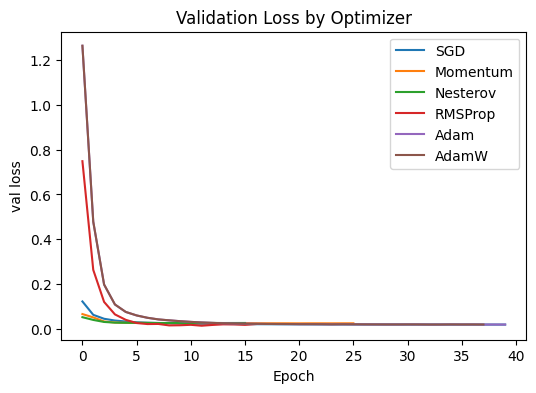

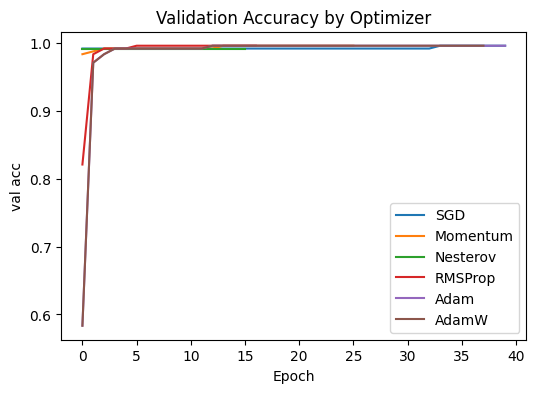

In [134]:
plot_metric(histories, labels, 'val_loss', 'Validation Loss by Optimizer')
plot_metric(histories, labels, 'val_acc', 'Validation Accuracy by Optimizer')

## Experiment B: Regularization ablation (L1/L2/Dropout)
We test None vs. **L2** vs. **L1** vs. **Dropout (p=0.5)**. Keep optimizer fixed for fairness.

In [135]:
histories = []
labels = []

for l1, l2, dropout_p, name in [
    (0.0, 0.0, 0.0, 'none'),
    (0.0, 1e-3, 0.0, 'L2=1e-3'),
    (1e-4, 0.0, 0.0, 'L1=1e-4'),
    (0.0, 0.0, 0.5, 'Dropout p=0.5'),
]:
    model = MLP(input_dim=input_dim, hidden_sizes=[64, 64], num_classes=num_classes,
                activation='relu', use_batchnorm=False, dropout_p=dropout_p, init='he', seed=123)
    opt = SGDMomentum(lr=5e-2, momentum=0.9)
    history = train(model, opt, X_train, y_train, X_val, y_val,
                 epochs=40, batch_size=64, l1=l1, l2=l2, early_stopping_patience=5, seed=123, verbose=False)
    val_acc = model.accuracy(X_val, y_val)
    print(f'{name:15s} | val_acc={val_acc:.3f}')

    histories.append(history)
    labels.append(name)

none            | val_acc=0.996
L2=1e-3         | val_acc=0.996
L1=1e-4         | val_acc=0.996
Dropout p=0.5   | val_acc=1.000


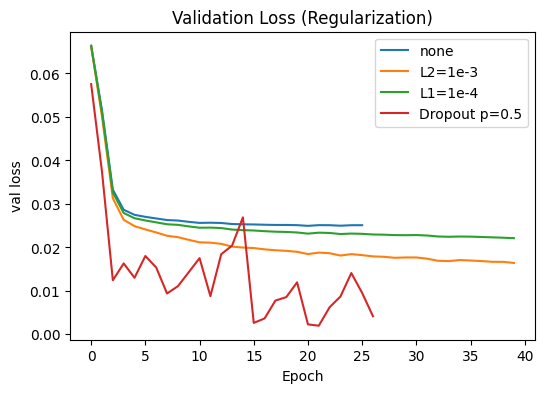

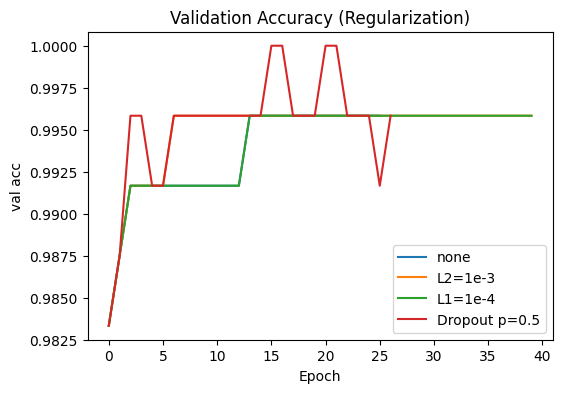

In [136]:
plot_metric(histories, labels, 'val_loss', 'Validation Loss (Regularization)')
plot_metric(histories, labels, 'val_acc', 'Validation Accuracy (Regularization)')

## Experiment C: BatchNorm on/off (with recommended ordering)
Compare MLP **with** vs. **without** BatchNorm (Linear -> BN -> ReLU -> [Dropout]). Keep optimizer and budget fixed.

In [137]:
def run_batch_norm(use_batch_norm, name):
    model = MLP(input_dim=input_dim, hidden_sizes=[64, 64], num_classes=num_classes,
                activation='relu', use_batchnorm=use_batch_norm, dropout_p=0.3, init='he', seed=123)
    optimizer = SGDMomentum(lr=5e-2, momentum=0.9)
    history = train(model, optimizer, X_train, y_train, X_val, y_val,
                 epochs=40, batch_size=64, l1=0.0, l2=0.0, early_stopping_patience=5, seed=123, verbose=False)
    val_acc = model.accuracy(X_val, y_val)

    print(f'{name:8s} | val_acc={val_acc:.3f}')
    return history, name

batch_norm_history, _ = run_batch_norm(True, 'with BN')
no_batch_norm_history, _ = run_batch_norm(False, 'no BN')

with BN  | val_acc=0.996
no BN    | val_acc=0.996


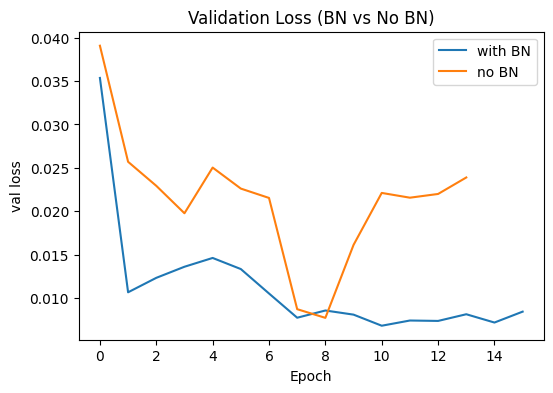

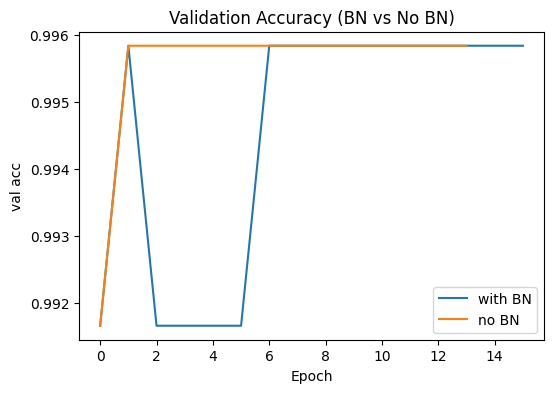

In [138]:
plot_metric([batch_norm_history, no_batch_norm_history], ['with BN', 'no BN'], 'val_loss', 'Validation Loss (BN vs No BN)')
plot_metric([batch_norm_history, no_batch_norm_history], ['with BN', 'no BN'], 'val_acc', 'Validation Accuracy (BN vs No BN)')

## Experiment C: Micro-batch ablation (Gradient Accumulation)
Keep optimizer fixed for fairness; hold logical batch_size constant
and vary micro_batch_size ∈ {None, 32, 16, 8, 4, 1}

no-accum     | val_acc=0.996
micro=32 (x2) | val_acc=0.992
micro=16 (x4) | val_acc=0.992
micro=8  (x8) | val_acc=0.992
micro=4  (x16) | val_acc=0.992
micro=1  (x64) | val_acc=0.992


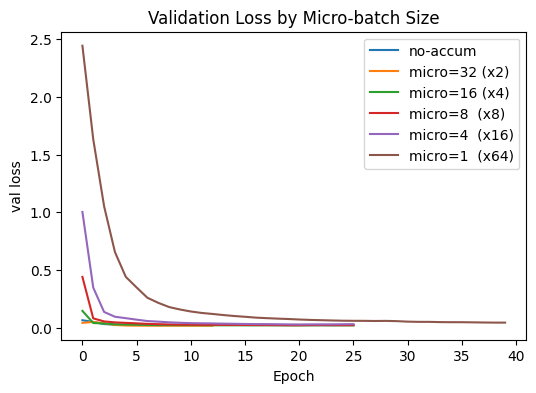

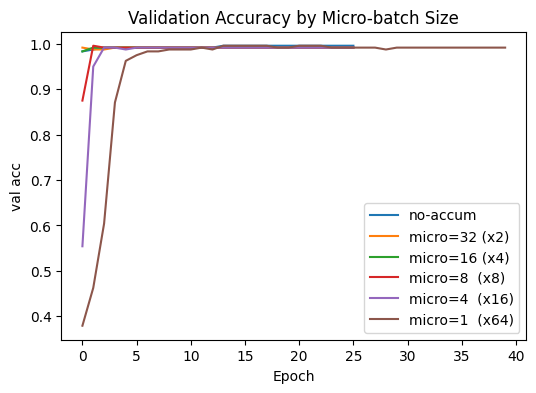

In [139]:
histories_mb = []
labels_mb = []

logical_batch_size = 64   
optimizer_ctor = lambda: SGDMomentum(lr=5e-2, momentum=0.9)  

for micro_bs, name in [
    (None, 'no-accum'),       
    (32,   'micro=32 (x2)'),   
    (16,   'micro=16 (x4)'),
    (8,    'micro=8  (x8)'),
    (4,    'micro=4  (x16)'),
    (1,    'micro=1  (x64)'),
]:
    model = MLP(input_dim=input_dim, hidden_sizes=[64, 64], num_classes=num_classes,
                activation='relu', use_batchnorm=False, dropout_p=0.0, init='he', seed=123)

    opt = optimizer_ctor()

    history = train(model, opt, X_train, y_train, X_val, y_val,
                    epochs=40,
                    batch_size=logical_batch_size,      
                    l1=0.0, l2=0.0,
                    early_stopping_patience=5,
                    seed=123,
                    verbose=False,
                    micro_batch_size=micro_bs)           

    val_acc = model.accuracy(X_val, y_val)
    print(f'{name:12s} | val_acc={val_acc:.3f}')

    histories_mb.append(history)
    labels_mb.append(name)

# Plot like before
plot_metric(histories_mb, labels_mb, 'val_loss', 'Validation Loss by Micro-batch Size')
plot_metric(histories_mb, labels_mb, 'val_acc',  'Validation Accuracy by Micro-batch Size')